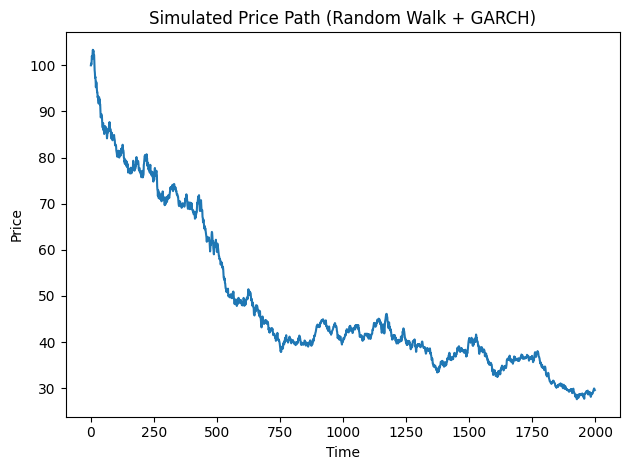

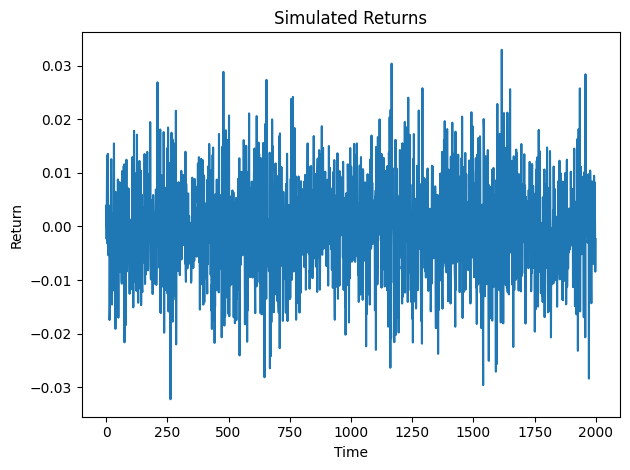

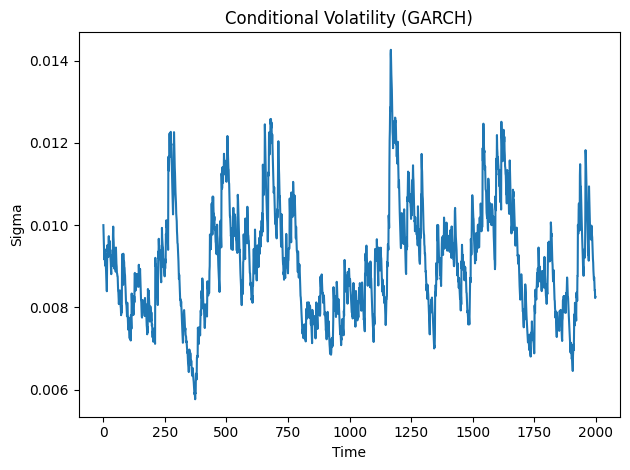

In [11]:
# -*- coding: utf-8 -*-
"""
Random Walk + GARCH(1,1) Simulation
------------------------------------------------------
模型定义：

收益率:
    r_t = mu + sigma_t * epsilon_t

GARCH(1,1):
    sigma_t^2 = omega + alpha * r_{t-1}^2 + beta * sigma_{t-1}^2

价格:
    S_t = S_{t-1} * exp(r_t)

说明：
1. alpha + beta < 1 保证平稳性
2. 使用几何随机游走保证价格非负
3. 本程序可直接运行
"""

import numpy as np
import matplotlib.pyplot as plt


def simulate_garch_random_walk(
    T=2000,
    S0=100.0,
    mu=0.0,
    omega=1e-6,
    alpha=0.05,
    beta=0.94,
    seed=42
):
    """
    生成随机游走 + GARCH(1,1) 序列

    参数:
        T: 时间长度
        S0: 初始价格
        mu: 漂移项
        omega, alpha, beta: GARCH参数
        seed: 随机种子

    返回:
        S: 价格序列
        r: 收益率序列
        sigma: 波动率序列
    """

    # 参数检查
    if alpha + beta >= 1:
        raise ValueError("alpha + beta 必须小于 1 才能保证平稳性")

    np.random.seed(seed)

    # 初始化数组
    r = np.zeros(T)
    sigma2 = np.zeros(T)
    sigma = np.zeros(T)
    S = np.zeros(T)

    # 初始条件
    sigma2[0] = omega / (1 - alpha - beta)  # 无条件方差
    sigma[0] = np.sqrt(sigma2[0])
    S[0] = S0

    # 主循环
    for t in range(1, T):
        epsilon = np.random.normal(0, 1)  # 标准正态噪声
        r[t] = mu + sigma[t - 1] * epsilon
        sigma2[t] = omega + alpha * r[t - 1]**2 + beta * sigma2[t - 1]
        sigma[t] = np.sqrt(sigma2[t])
        S[t] = S[t - 1] * np.exp(r[t])

    return S, r, sigma


if __name__ == "__main__":

    # ====== 模型参数 ======
    T = 2000
    S0 = 100.0
    mu = -0.001 # 0.0001
    omega = 1e-6
    alpha = 0.05
    beta = 0.94

    # ====== 生成数据 ======
    S, r, sigma = simulate_garch_random_walk(
        T=T,
        S0=S0,
        mu=mu,
        omega=omega,
        alpha=alpha,
        beta=beta
    )

    # ====== 绘制价格 ======
    plt.figure()
    plt.plot(S)
    plt.title("Simulated Price Path (Random Walk + GARCH)")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.tight_layout()
    plt.show()

    # ====== 绘制收益率 ======
    plt.figure()
    plt.plot(r)
    plt.title("Simulated Returns")
    plt.xlabel("Time")
    plt.ylabel("Return")
    plt.tight_layout()
    plt.show()

    # ====== 绘制波动率 ======
    plt.figure()
    plt.plot(sigma)
    plt.title("Conditional Volatility (GARCH)")
    plt.xlabel("Time")
    plt.ylabel("Sigma")
    plt.tight_layout()
    plt.show()
